## __Chatbot with message summarization & external DB memory__
__Objective__

But, what if we want our Chatbot to have memory that persists indefinitely?

Now, we'll introduce some more advanced checkpointers that support external databases.

Here, we'll show how to use `Sqlite` as a checkpointer, but other checkpointers, such as Postgres are available!

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from typing_extensions import Literal
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langgraph.graph import END, MessagesState
load_dotenv()

NV_API_KEY = os.getenv("NV_API_KEY")
NV_API_URL = os.getenv("NV_API_URL")


model = ChatOpenAI(
    model="openai/gpt-oss-120b",
    openai_api_key=NV_API_KEY,
    openai_api_base=NV_API_URL,
    temperature=0.001,
    top_p=1,
    max_tokens=4096,
    streaming=False,
    extra_body={"reasoning_effort": "low"}
)

class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State)-> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END


### __Sqlite__
A good starting point here is the `SqliteSaver` checkpointer.

_Sqlite is a small, fast, highly popular SQL database._

If we supply "`:memory:`" it creates an __in-memory Sqlite__ database.

In [2]:
import sqlite3
# In memory
conn = sqlite3.connect(":memory:", check_same_thread = False)

But, if we supply a db path, then it will create a database for us!

In [4]:
# pull file if it doesn't exist and connect to local db
!mkdir -p state_db && [ ! -f state_db/demonstration.db ] && curl -L -o state_db/demonstration.db "https://github.com/shekh-abdullah-ayubi/LangChain-Ecosystem/tree/main/03-LangGraph-Data-Modeling/state_db/demonstration.db"

db_path = "state_db/demonstration.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

In [6]:
# Here is our checkpointer 
from langgraph.checkpoint.sqlite import SqliteSaver

memory = SqliteSaver(conn)

Now, we just re-compile with our `sqlite checkpointer`.

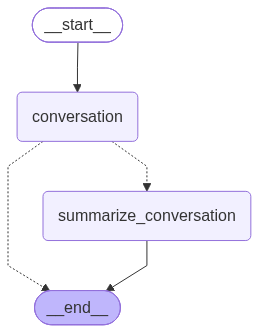

In [7]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="Hi! I'm Shekh Abdullah Ayubi")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="Tell me who I am?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="I Love my Parents!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hello, Shekh Abdullah Ayubi! 👋  
How can I assist you today?
================================== Ai Message ==================================

You’ve introduced yourself as **Shekh Abdullah Ayubi**.  
Beyond that, I don’t have any other details about you—your background, interests, profession, or anything else you’d like to share. If you’d like me to tailor my responses or help with something specific, just let me know a bit more about yourself!
================================== Ai Message ==================================

That’s wonderful to hear! ❤️ Family love is one of the most grounding and rewarding things in life.  

If you ever want ideas for showing appreciation, planning a special surprise, or just chatting about family‑related topics, let me know—I’m happy to help!


Let's confirm that our state is saved locally.

In [9]:
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="Hi! I'm Shekh Abdullah Ayubi", additional_kwargs={}, response_metadata={}, id='f77f1fab-6941-4654-a781-3dc4847bbb27'), AIMessage(content='Hello, Shekh Abdullah Ayubi! 👋  \nHow can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 73, 'total_tokens': 112, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': None, 'id': 'chatcmpl-bacd4093821a1717', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd346-891c-7633-b9ef-6a70f2d3eb8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 39, 'total_tokens': 112, 'input_token_details': {}, 'output_token_details': {}}), HumanMessage(content='Tell me who I am?', additional_kwargs={}, response_metadata={}, id='0777bc4e-bb6f-45ec-aca2-95447cbac4ec'), AIMessa

#### __Persisting state__
Using database like `Sqlite` means state is `persisted`!

For example, we can re-start the notebook kernel and see that we can still load from Sqlite DB on disk.

In [10]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="Hi! I'm Shekh Abdullah Ayubi", additional_kwargs={}, response_metadata={}, id='f77f1fab-6941-4654-a781-3dc4847bbb27'), AIMessage(content='Hello, Shekh Abdullah Ayubi! 👋  \nHow can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 73, 'total_tokens': 112, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': None, 'id': 'chatcmpl-bacd4093821a1717', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd346-891c-7633-b9ef-6a70f2d3eb8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 39, 'total_tokens': 112, 'input_token_details': {}, 'output_token_details': {}}), HumanMessage(content='Tell me who I am?', additional_kwargs={}, response_metadata={}, id='0777bc4e-bb6f-45ec-aca2-95447cbac4ec'), AIMessa